## Projet e-commerce


### 1- Data Import

In [2029]:
# Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les datasets 
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

In [2030]:
# Explorons rapidement les données 
customers.info()
orders.info()
order_items.info()
payments.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

### 2- Data Cleaning

- Valeurs manquantes

In [1]:
# Vérifions les valeurs manquantes

# Customers
customers.isnull().sum()

NameError: name 'customers' is not defined

In [ ]:
# Orders
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [ ]:
# Order_items
order_items.isnull().sum()


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [ ]:
# Payments
payments.isnull().sum()


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [ ]:
#Products
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

- Nettoyage des valeurs manquantes

In [ ]:

# a- Table product
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [ ]:
# Catégorie produit
products["product_category_name"] = products["product_category_name"].fillna("unknown")

In [ ]:
products["product_name_lenght"] = products["product_name_lenght"].fillna(0)

products["product_description_lenght"] = products["product_description_lenght"].fillna(0)

products["product_photos_qty"] = products["product_photos_qty"].fillna(0)

products["product_weight_g"] = products["product_weight_g"].fillna(products["product_weight_g"].median())
products["product_length_cm"] = products["product_length_cm"].fillna(products["product_length_cm"].median())

products["product_height_cm"] = products["product_height_cm"].fillna(products["product_height_cm"].median())

products["product_width_cm"] = products["product_width_cm"].fillna(products["product_width_cm"].median())

products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [ ]:
# Pour la variable orders
orders.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [ ]:
# Convertir les dates
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])

orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])

orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])


In [ ]:
# Vérifions les statuts des commandes
# Très utile pour comprendre les valeurs manquantes
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [ ]:
# Créer quelques variables dans orders

# Temps de livraison
orders["delivery_time"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

In [ ]:
# Retard de livraison
orders["delivery_delay"] = (
    orders["order_delivered_customer_date"] -
    orders["order_estimated_delivery_date"]
).dt.days

In [ ]:
# Remplir les NaN de ces variables par 0
orders["delivery_time"] = orders["delivery_time"].fillna(0)
orders["delivery_delay"] = orders["delivery_delay"].fillna(0)

- Doublons

In [ ]:
# Vérification des doublons

customers.duplicated().sum()
orders.duplicated().sum()
order_items.duplicated().sum()
payments.duplicated().sum()
products.duplicated().sum()

0

- Fusion des tables

Fusionner les tables qui contiendra : les commandes, les clients, les produits, 
les paiements et prix qu'on va appeller "ecommerce_df"

In [ ]:

# Fusion Orders et Customers : chaque client est lié à un client via: customer_id

ecommerce_df = orders.merge(customers, on="customer_id", how="left")


In [ ]:
# Ajouter les produits commandés via :order_id
ecommerce_df = ecommerce_df.merge(order_items, on="order_id", how="left")

In [ ]:
# Ajouter les paiements via : order_id
ecommerce_df = ecommerce_df.merge(payments, on="order_id", how="left")

In [ ]:
# Ajouter les informations produits via : product_id
ecommerce_df = ecommerce_df.merge(products, on="product_id", how="left")

- Vérifions la table finale

In [ ]:
ecommerce_df.head()
ecommerce_df.shape
ecommerce_df.info()
ecommerce_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118434 non-null  object        
 1   customer_id                    118434 non-null  object        
 2   order_status                   118434 non-null  object        
 3   order_purchase_timestamp       118434 non-null  datetime64[ns]
 4   order_approved_at              118258 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116360 non-null  datetime64[ns]
 6   order_delivered_customer_date  115037 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118434 non-null  datetime64[ns]
 8   delivery_time                  118434 non-null  float64       
 9   delivery_delay                 118434 non-null  float64       
 10  customer_unique_id             118434 non-null  object        
 11  

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
delivery_time                       0
delivery_delay                      0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price                             830
freight_value                     830
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
product_category_name             830
product_name_lenght               830
product_desc

In [ ]:
ecommerce_df.duplicated().sum()

0

- Nettoyage des valeurs manquantes après le fusionnement 

In [ ]:
#  Catégorie produit
ecommerce_df["product_category_name"] = ecommerce_df["product_category_name"].fillna("unknown")

In [ ]:
# On remplace par la médiane

ecommerce_df["product_weight_g"].fillna(ecommerce_df["product_weight_g"].median(), inplace=True)

ecommerce_df["product_length_cm"].fillna(ecommerce_df["product_length_cm"].median(), inplace=True)

ecommerce_df["product_height_cm"].fillna(ecommerce_df["product_height_cm"].median(), inplace=True)

ecommerce_df["product_width_cm"].fillna(ecommerce_df["product_width_cm"].median(), inplace=True)

C:\Users\clifo\AppData\Local\Temp\ipykernel_7292\1151666257.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ecommerce_df["product_weight_g"].fillna(ecommerce_df["product_weight_g"].median(), inplace=True)
C:\Users\clifo\AppData\Local\Temp\ipykernel_7292\1151666257.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are set

In [ ]:
# Valeurs manquantes order_items
# Ces lignes correspondent souvent à des commandes annulées et commandes non finalisées
# Si certaines lignes n’ont pas de prix, 
# Ici la bonne pratique est de les supprimer

ecommerce_df = ecommerce_df.dropna(subset=["price"])

In [ ]:
# Paiements manquants
# Très faible,On peut simplement supprimer :
ecommerce_df = ecommerce_df.dropna(subset=["payment_value"])


In [ ]:
ecommerce_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
delivery_time                       0
delivery_delay                      0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
product_category_name               0
product_name_lenght                 0
product_desc

In [ ]:
# On peut remplacer les NaN par 0.

ecommerce_df["delivery_time"] = ecommerce_df["delivery_time"].fillna(0)

ecommerce_df["delivery_delay"] = ecommerce_df["delivery_delay"].fillna(0)

In [ ]:
ecommerce_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
delivery_time                       0
delivery_delay                      0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
product_category_name               0
product_name_lenght                 0
product_desc

- Créer les variables business

In [ ]:
# Créons des variables pour l'analyse business

# Revenue total
ecommerce_df["revenue"] = ecommerce_df["price"] + ecommerce_df["freight_value"]

# Année de commande
ecommerce_df["order_year"] = ecommerce_df["order_purchase_timestamp"].dt.year

# Mois de commande
ecommerce_df["order_month"] = ecommerce_df["order_purchase_timestamp"].dt.to_period("M")

# Jour de la semaine
ecommerce_df["order_day"] = ecommerce_df["order_purchase_timestamp"].dt.day_name()

3- Analyse exploratoire des données (EDA)

In [ ]:
# 1- Apperçu général du dataset
ecommerce_df.head()
ecommerce_df.shape
ecommerce_df.info()
ecommerce_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 117601 entries, 0 to 118433
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117601 non-null  object        
 1   customer_id                    117601 non-null  object        
 2   order_status                   117601 non-null  object        
 3   order_purchase_timestamp       117601 non-null  datetime64[ns]
 4   order_approved_at              117586 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116356 non-null  datetime64[ns]
 6   order_delivered_customer_date  115034 non-null  datetime64[ns]
 7   order_estimated_delivery_date  117601 non-null  datetime64[ns]
 8   delivery_time                  117601 non-null  float64       
 9   delivery_delay                 117601 non-null  float64       
 10  customer_unique_id             117601 non-null  object        
 11  custo

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
delivery_time                       0
delivery_delay                      0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
product_category_name               0
product_name_lenght                 0
product_desc

- Statistiques descriptives

In [ ]:
# Statistiques descriptives

ecommerce_df.describe


<bound method NDFrame.describe of                                 order_id                       customer_id  \
0       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3       53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4       47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
...                                  ...                               ...   
118429  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
118430  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
118431  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
118432  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
118433  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

       order_status order_pur

- Analyse des valeurs aberrantes

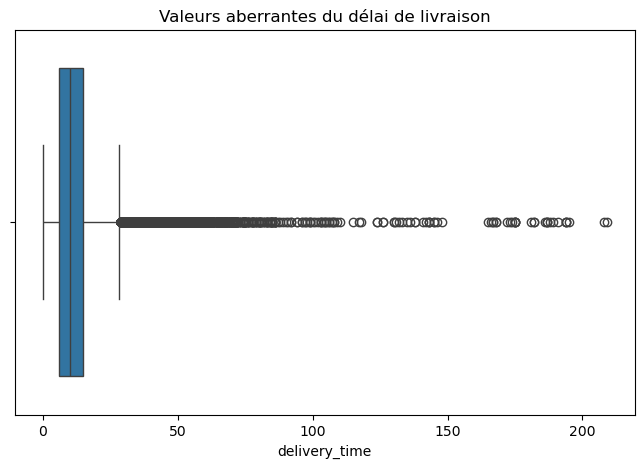

In [ ]:
# Boxplot des prix

plt.figure(figsize=(8,5))
sns.boxplot(x=ecommerce_df["delivery_time"])
plt.title("Valeurs aberrantes du délai de livraison")
plt.show()

In [ ]:
# Détection avec la méthode IQR

Q1 = ecommerce_df["delivery_time"].quantile(0.25)
Q3 = ecommerce_df["delivery_time"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
upper_limit

28.5

In [ ]:
# Identifier les valeurs extrêmes
outliers = ecommerce_df[ecommerce_df["delivery_time"] > upper_limit]
outliers.shape

(5785, 36)

Analyse des valeurs aberrantes du délai de livraison

La méthode IQR a été utilisée pour identifier les valeurs aberrantes dans la variable `delivery_time`.

La limite supérieure calculée est **28.5 jours**.

Les commandes ayant un délai de livraison supérieur à cette valeur sont considérées comme des observations potentiellement aberrantes.

Au total, **5785 commandes** présentent un délai de livraison supérieur à cette limite.

Ces délais élevés peuvent être expliqués par :

- des retards logistiques
- des problèmes de transport
- des livraisons dans des régions éloignées
- ou des anomalies dans les données

Afin d'améliorer la lisibilité des visualisations, une version filtrée des données sera utilisée pour certaines analyses graphiques.

In [ ]:
# Créer un dataset filtré (pour les graphiques)
ecommerce_filtered = ecommerce_df[ecommerce_df["delivery_time"] <= upper_limit]

In [ ]:
# vérifier le nouveau dataset 
ecommerce_filtered.shape

(111816, 36)

- Distributions

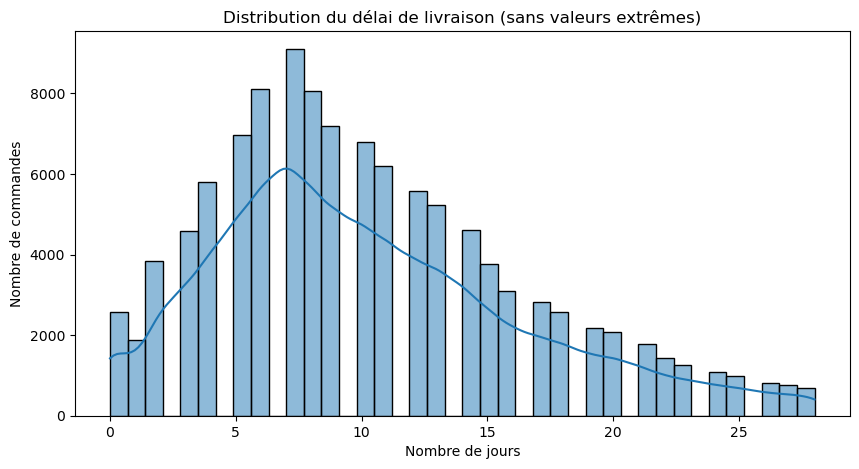

In [ ]:

# Ditribution du délai de livraison
plt.figure(figsize=(10,5))

sns.histplot(ecommerce_filtered["delivery_time"], bins=40, kde=True)

plt.title("Distribution du délai de livraison (sans valeurs extrêmes)")
plt.xlabel("Nombre de jours")
plt.ylabel("Nombre de commandes")

plt.show()

<Axes: xlabel='delivery_time', ylabel='Count'>

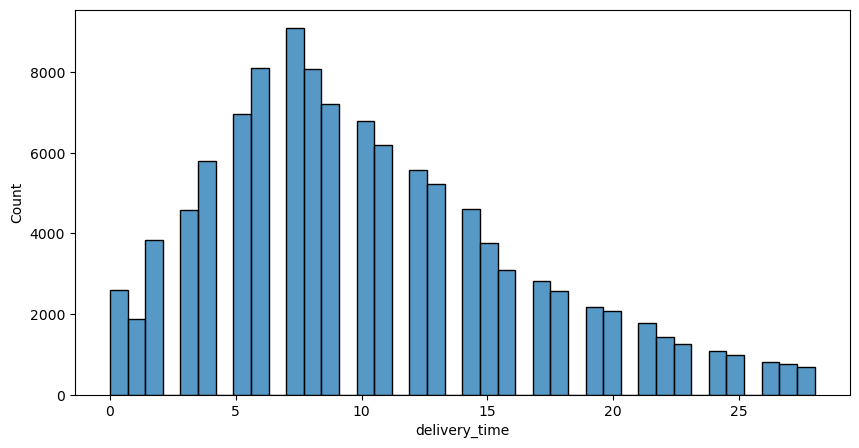

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(ecommerce_filtered["delivery_time"], bins=40)

<Axes: xlabel='price', ylabel='Count'>

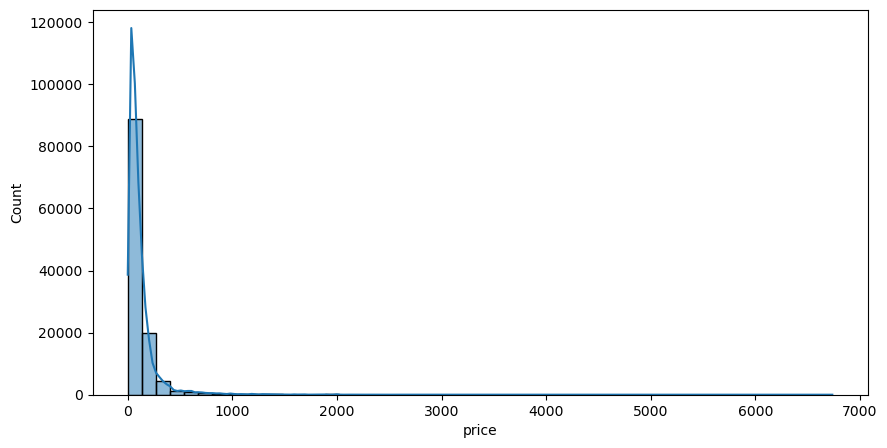

In [ ]:
# Distribution des prix
plt.figure(figsize=(10,5))
sns.histplot(ecommerce_df["price"], bins=50, kde=True)

La distribution des prix est fortement asymétrique.

La majorité des produits ont un prix relativement faible,tandis que quelques produits présentent des prix très élevés.

Cela suggère que la plateforme propose principalement des produits accessibles avec quelques articles premium.

<Axes: xlabel='order_status', ylabel='count'>

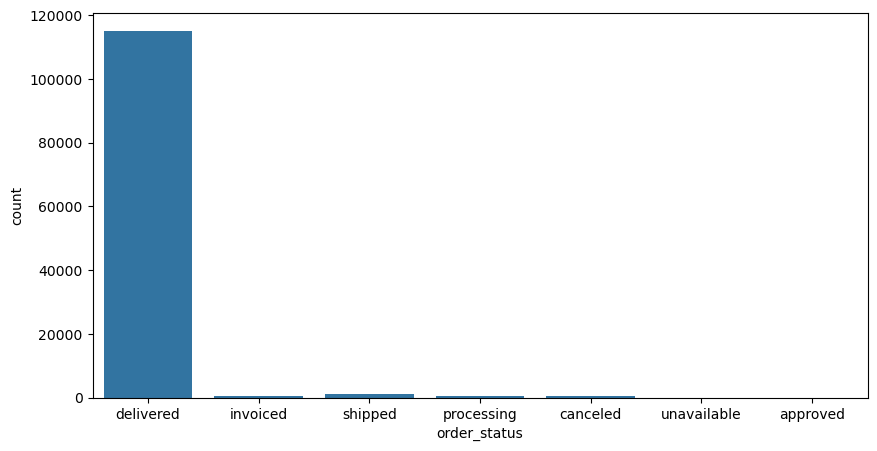

In [ ]:
# Distribution Statut des commandes
plt.figure(figsize=(10,5))
sns.countplot(x="order_status", data=ecommerce_df)

C:\Users\clifo\AppData\Local\Temp\ipykernel_7292\1944674260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="payment_type", data=ecommerce_df, palette="viridis")


<Axes: xlabel='payment_type', ylabel='count'>

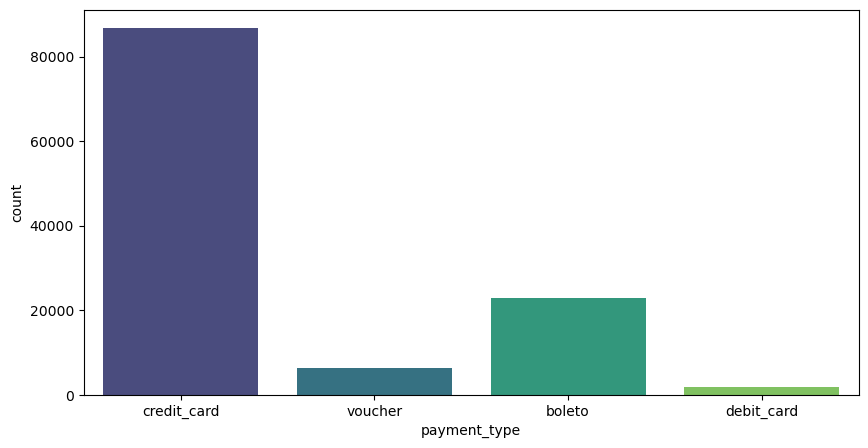

In [ ]:
# Répartition Méthodes de paiement
plt.figure(figsize=(10,5))
sns.countplot(x="payment_type", data=ecommerce_df, palette="viridis")

- La carte de crédit est la méthode de paiement la plus utilisée.

- Cela indique que les clients préfèrent les paiements rapides et sécurisés. Les autres méthodes comme boleto et voucher sont utilisées mais restent minoritaires.

<Axes: xlabel='product_category_name'>

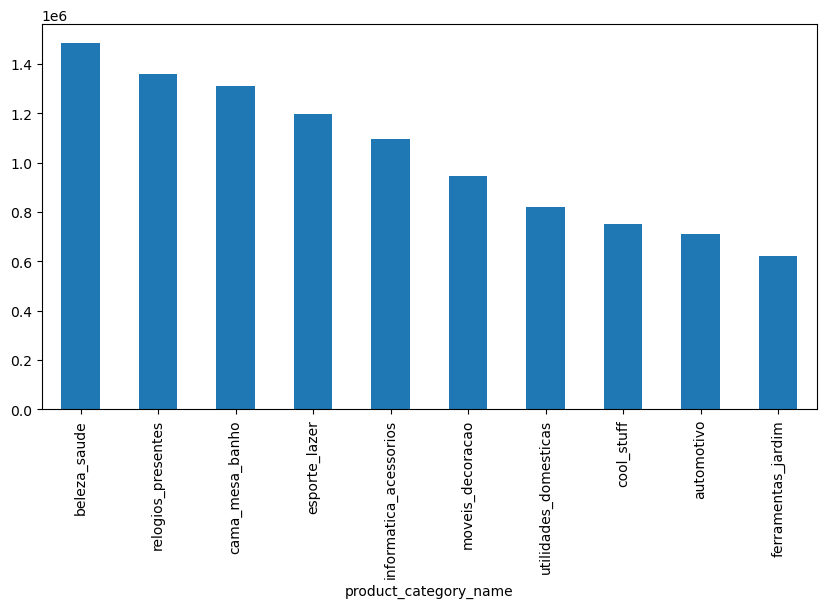

In [ ]:
# Top catégories produits
plt.figure(figsize=(10,5))
top_categories = ecommerce_df.groupby("product_category_name")["revenue"].sum().sort_values(ascending=False).head(10)

top_categories.plot(kind="bar")

La majorité des ventes est concentrée sur quelques catégories produits comme beleza_saude, relogios_presentes, ...

<Axes: xlabel='customer_city'>

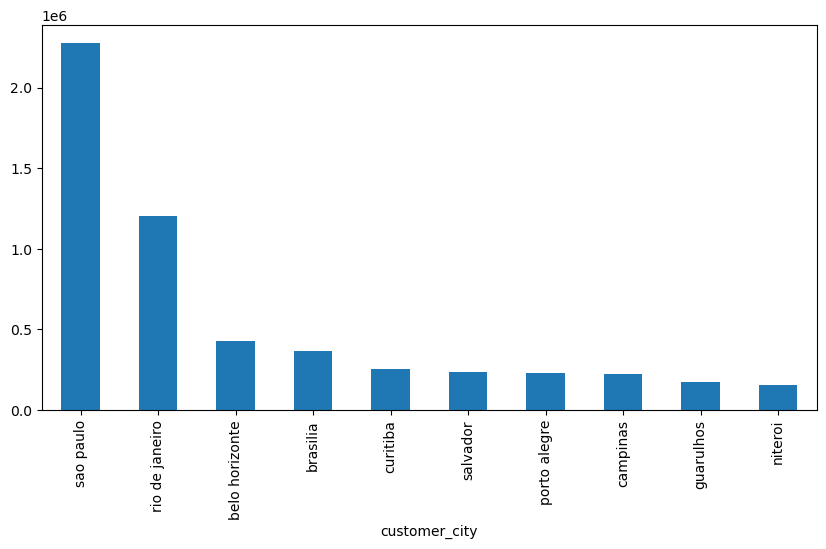

In [ ]:
# Top villes
plt.figure(figsize=(10,5))
top_cities = ecommerce_df.groupby("customer_city")["revenue"].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind="bar")

La majorité du chiffre d'affaires provient des grandes villes comme São Paulo et Rio de Janeiro.
Ces villes représentent les principaux marchés pour la plateforme e-commerce.

- Corrélation 

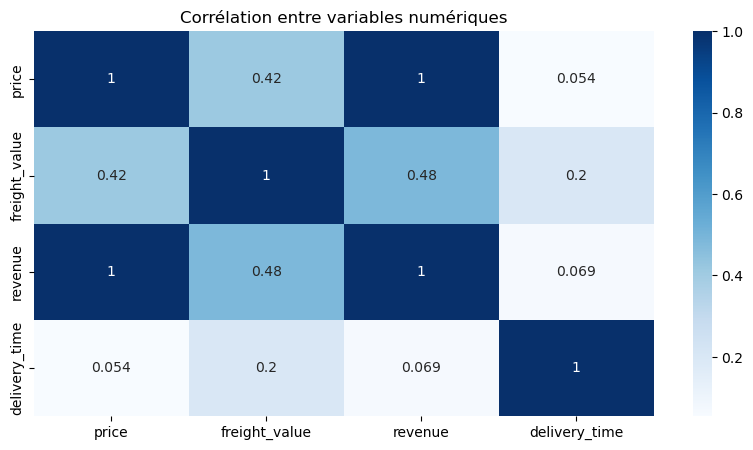

In [ ]:
# Corrélations

corr = ecommerce_df[["price", "freight_value", "revenue", "delivery_time"]].corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Corrélation entre variables numériques")
plt.show()

4- Analyse business et KPI principaux

- Analyse des ventes

In [ ]:
# Chiffre d'affaires total

total_revenue = ecommerce_df["revenue"].sum()
total_revenue

16566543.850000001

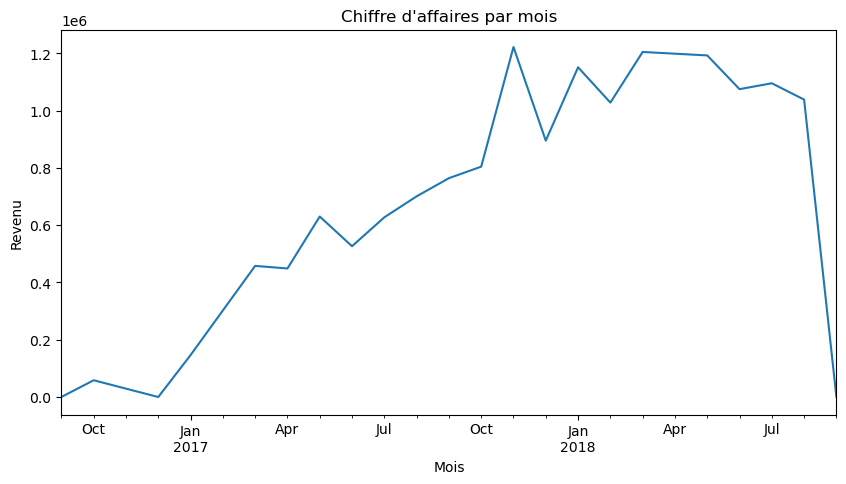

In [ ]:
# Evolution du Chiffre d'affaire par mois

revenue_by_month = ecommerce_df.groupby("order_month")["revenue"].sum()

plt.figure(figsize=(10,5))
revenue_by_month.plot()

plt.title("Chiffre d'affaires par mois")
plt.xlabel("Mois")
plt.ylabel("Revenu")

plt.show()

Ce graphique montre une évolution progressive du chiffre d'affaires au fil du temps,indiquant une croissance de la plateforme e-commerce.

In [ ]:
# Nombre total de commandes
total_orders = ecommerce_df["order_id"].nunique()

In [ ]:
# Produit les plus vendus
top_products = ecommerce_df.groupby("product_id")["order_item_id"].count().sort_values(ascending=False).head(10)

top_products

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    536
99a4788cb24856965c36a24e339b6058    525
422879e10f46682990de24d770e7f83d    505
389d119b48cf3043d311335e499d9c6b    406
368c6c730842d78016ad823897a372db    395
53759a2ecddad2bb87a079a1f1519f73    389
d1c427060a0f73f6b889a5c7c61f2ac4    357
53b36df67ebb7c41585e8d54d6772e08    327
154e7e31ebfa092203795c972e5804a6    283
3dd2a17168ec895c781a9191c1e95ad7    278
Name: order_item_id, dtype: int64

In [ ]:
# Taux de retard

late_orders = (ecommerce_df["delivery_delay"] > 0).mean()

late_orders

0.06400455778437258

6.4% des commandes sont livrées en retard.

In [ ]:
# Délai moyen de livraison

avg_delivery = ecommerce_df["delivery_time"].mean()

avg_delivery

11.755809899575684

Le délai moyen de livraison est de 12 jours.

In [ ]:
# Panier moyen (Average Order Value)

total_revenue = ecommerce_df["revenue"].sum()
total_orders = ecommerce_df["order_id"].nunique()

average_order_value = total_revenue / total_orders

average_order_value

167.90699690873157

Le panier moyen est de 168$

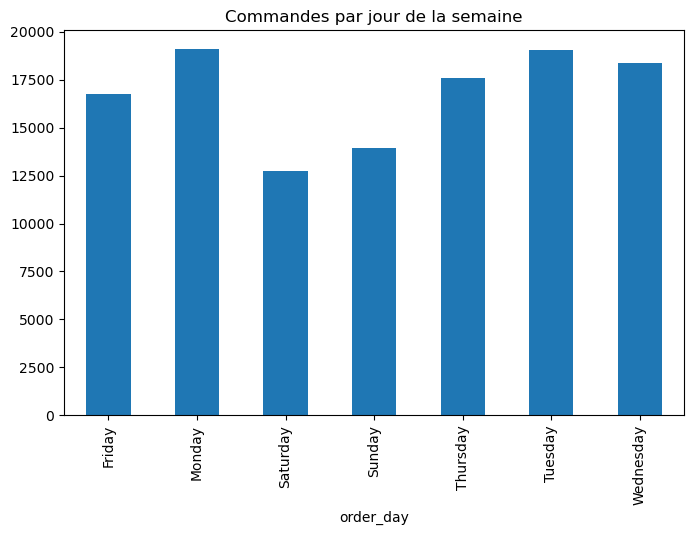

In [ ]:
#Analyse du jour de la semaine

orders_by_day = ecommerce_df.groupby("order_day")["order_id"].count()

plt.figure(figsize=(8,5))

orders_by_day.plot(kind="bar")

plt.title("Commandes par jour de la semaine")
plt.show()

- Analyse de rétention des clients et du churn

In [ ]:
# Nombre d’achats par client
orders_per_customer = ecommerce_df.groupby("customer_unique_id")["order_id"].nunique()

orders_per_customer.describe()

count    95419.000000
mean         1.034018
std          0.211235
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: order_id, dtype: float64

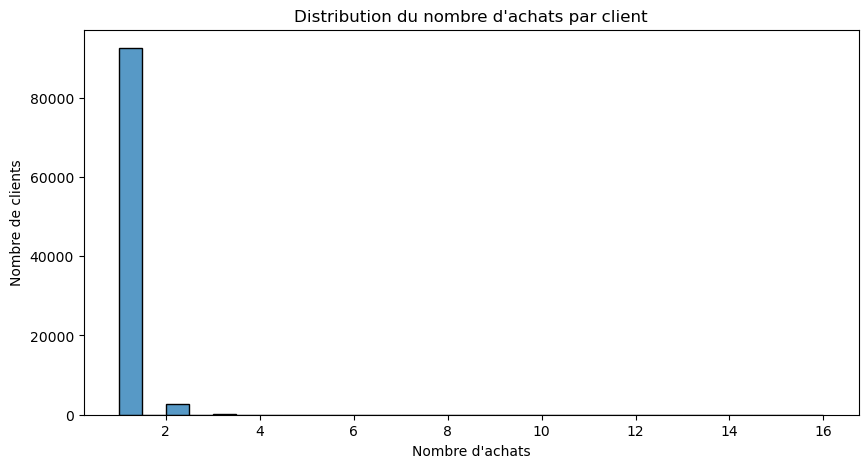

In [ ]:
# Distribution des achats par client
plt.figure(figsize=(10,5))

sns.histplot(orders_per_customer, bins=30)

plt.title("Distribution du nombre d'achats par client")
plt.xlabel("Nombre d'achats")
plt.ylabel("Nombre de clients")

plt.show()

In [ ]:
# Pourcentage de clients récurrents
repeat_customers = (orders_per_customer > 1).sum()
total_customers = orders_per_customer.count()

retention_rate = repeat_customers / total_customers

retention_rate

0.030528511093178508

L'analyse montre que 3% des clients ont effectué plus d'un achat.
Cela indique le niveau de fidélité des clients sur la plateforme. Une faible rétention peut suggérer que la majorité des clients achètent une seule fois.

Analyse du churn client
Le churn correspond aux clients qui n’achètent plus. Dans ce dataset, on peut approximer le churn par : clients qui ont fait une seule commande.

In [ ]:
# Calcul du churn
one_time_customers = (orders_per_customer == 1).sum()

churn_rate = one_time_customers / total_customers

churn_rate

0.9694714889068214

Le taux de churn est estimé à 97%.Cela signifie que 97% des clients n'ont effectué qu'un seul achat et ne sont pas revenus sur la plateforme.

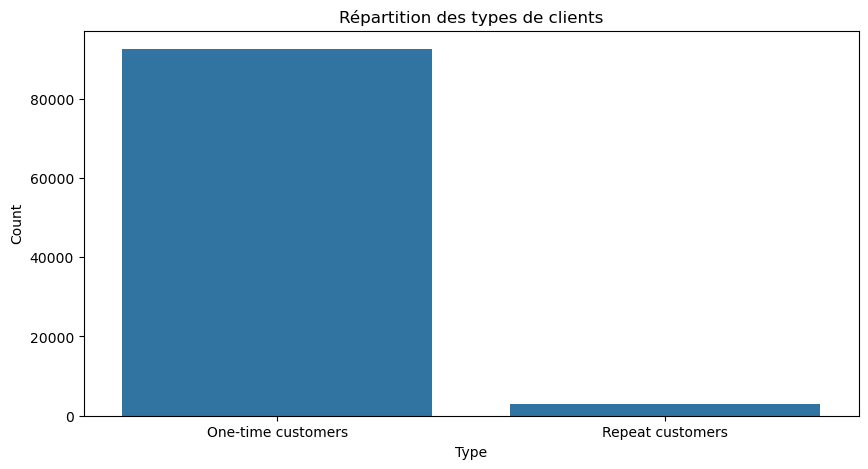

In [ ]:
customer_types = pd.DataFrame({
    "Type": ["One-time customers", "Repeat customers"],
    "Count": [one_time_customers, repeat_customers]
})

plt.figure(figsize=(10,5))

sns.barplot(x="Type", y="Count", data=customer_types)

plt.title("Répartition des types de clients")

plt.show()

In [ ]:
# Top des acheteurs
customer_revenue = ecommerce_df.groupby("customer_unique_id")["revenue"].sum()

top_customers = customer_revenue.sort_values(ascending=False).head(10)

top_customers

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
8af7ac63b2efbcbd88e5b11505e8098a    13281.71
c4b224d2c784bae11ae98b6ae9f2454c    11111.40
85963fd37bfd387aa6d915d8a1065486    10553.28
be74c431147c32ab2d7c7cef5e4a995f    10055.22
edf81e1f3070b9dac83ec83dacdbb9bc     8389.52
58483a1c055dfb600f57c5b867174542     8068.88
1033eef37a760a832f9b2332ce23fdc5     8030.46
da122df9eeddfedc1dc1f5349a1a690c     7571.63
301d1ce5a76b7e1bc47e5115bf5eb6ba     7413.70
Name: revenue, dtype: float64

Une petite proportion de clients génère une part importante du chiffre d'affaires.
La fidélisation des clients récurrents peut donc représenter un levier important pour augmenter les revenus.

In [ ]:
# Top des vendeurs
top_sellers = ecommerce_df.groupby("seller_id")["revenue"].sum().sort_values(ascending=False).head(10)

top_sellers

c:\Users\clifo\anaconda3\Lib\site-packages\IPython\core\displayhook.py:281: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


seller_id
53243585a1d6dc2643021fd1853d8905    258882.28
4869f7a5dfa277a7dca6462dcf3b52b2    258625.52
7c67e1448b00f6e969d365cea6b010ab    252549.32
4a3ca9315b744ce9f8e9374361493884    250635.29
fa1c13f2614d7b5c4749cbc52fecda94    214454.82
da8622b14eb17ae2831f4ac5b9dab84a    195751.05
7e93a43ef30c4f03f38b393420bc753a    189475.90
1025f0e2d44d7041d6cf58b6550e0bfa    176845.92
7a67c85e85bb2ce8582c35f2203ad736    172013.25
955fee9216a65b617aa5c0531780ce60    163183.53
Name: revenue, dtype: float64

In [ ]:
# Sauvegardons la base de données pour la suite d'analyse (Power Bi)

ecommerce_df.to_csv("ecommerce_final.csv", index=False)